In [1]:
import os
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"

import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patheffects as pe
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import roc_auc_score

from subspaces import *
from train_nli_box import NLITrainingData as NLITrainingDataBox
from model import *

device = "cpu"

# Load premise & composite hypotheses

In [21]:
premises = []
hypotheses = []
updates = []
labels = []

with open("./composite_entailment.txt", "r", encoding="utf-8") as f:
    next(f)
    for line in f:
        line = line.strip()
        if not line:
            continue  
        parts = line.split(".")
        premise = parts[0]
        hypothesis = parts[1]
        update = ",".join(parts[2:-1])
        label = int(parts[-1])
        premises.append(premise)
        hypotheses.append(hypothesis)
        updates.append(update)
        labels.append(label)
        
labels = (torch.tensor(labels, device=device) == 2).long()

flipped_labels = False
if flipped_labels:
    labels = 1 - labels
print("Loaded", len(premises), "rows")

Loaded 300 rows


In [23]:
config = NLITrainingDataBox.load("./nli_models/box64d_all-mpnet-base-v2_context35_seed13_2way/config.pt")

model = BoxTransformerClassifier(
    config.base_model_name, config.box_dim, cache_dir="./.cache"
);
model.load_state_dict(config.state_dict, strict=False);
model.eval();
model.to(device);

In [24]:
batch_size = 4
box_p = []
box_h = []
box_u = []
for i in tqdm(range(0, len(premises), batch_size)):
    box_p_batch = model.encode(premises[i:i+batch_size], max_length=config.max_length, device=device)
    box_h_batch = model.encode(hypotheses[i:i+batch_size], max_length=config.max_length, device=device)
    box_u_batch = model.encode(updates[i:i+batch_size], max_length=config.max_length, device=device)
    box_p.append(box_p_batch)
    box_h.append(box_h_batch)
    box_u.append(box_u_batch)
box_p = torch.cat(box_p)
box_u = torch.cat(box_u)
box_h = torch.cat(box_h)

  0%|          | 0/75 [00:00<?, ?it/s]

ROC AUC premise-update: 97.63
ROC AUC premise-composite: 91.51


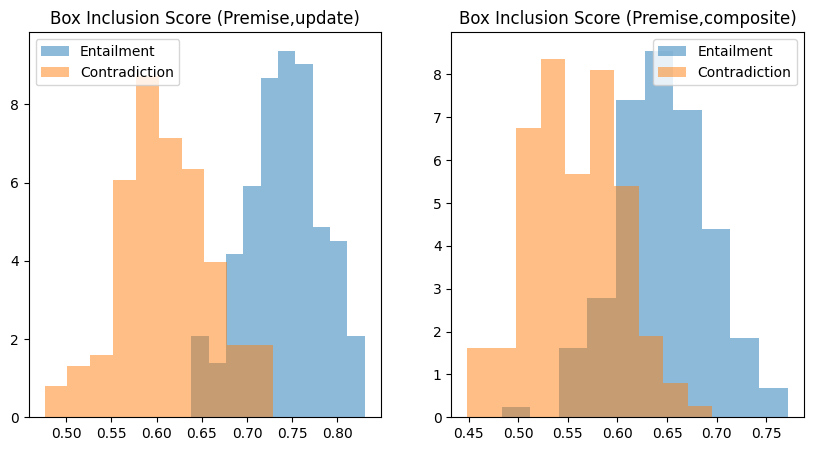

In [26]:
# Box intersection: composite = hypothesis AND update
comp_min = torch.max(box_h[:, 0], box_u[:, 0])  # max of mins
comp_max = torch.min(box_h[:, 1], box_u[:, 1])  # min of maxes

# Then score containment: P(composite | premise)
scores_pc = model.containment(box_p[:, 0], box_p[:, 1], comp_min, comp_max)
scores_pu = model.containment(box_p[:, 0], box_p[:, 1], box_u[:, 0], box_u[:, 1])

pu_auc = roc_auc_score(1-labels.detach().cpu().numpy(), scores_pu.detach().cpu().numpy())
pc_auc = roc_auc_score(1-labels.detach().cpu().numpy(), scores_pc.detach().cpu().numpy())
print(f"ROC AUC premise-update: {pu_auc*100:.2f}")
print(f"ROC AUC premise-composite: {pc_auc*100:.2f}")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(scores_pu[labels==0], alpha=0.5, density=True)
plt.hist(scores_pu[labels==1], alpha=0.5, density=True)
plt.legend(["Entailment", "Contradiction"])
plt.title("Box Inclusion Score (Premise,update)")
plt.subplot(1,2,2)
plt.hist(scores_pc[labels==0], alpha=0.5, density=True)
plt.hist(scores_pc[labels==1], alpha=0.5, density=True)
plt.title("Box Inclusion Score (Premise,composite)")
plt.legend(["Entailment", "Contradiction"])

ROC AUC premise-update: 4.86
ROC AUC premise-neg-composite: 38.36
Fraction of empty composite boxes: 1.000


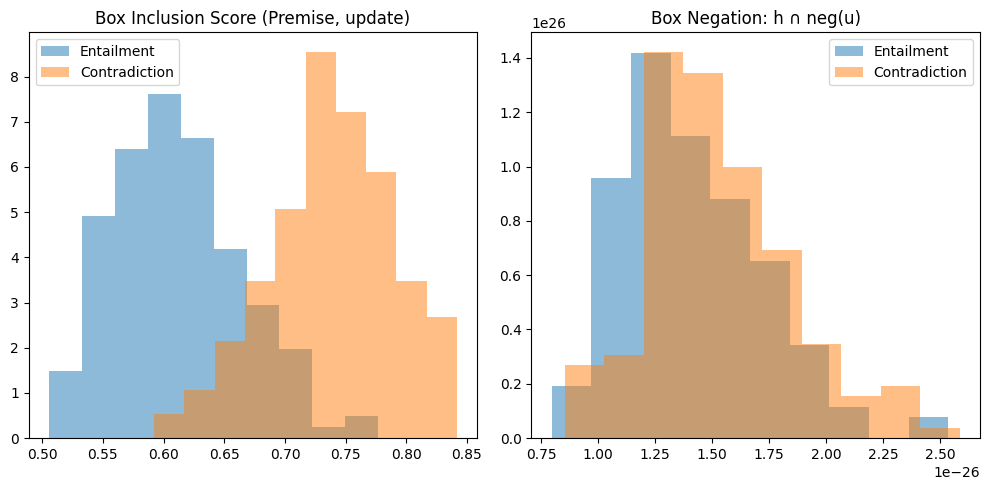

In [20]:
# Negation heuristic: negate the update box (mirror through origin),
# then intersect with hypothesis to get a stored representation.
# Analogous to vector baselines using -v for negation.
neg_u_min = -box_u[:, 1]  # negating flips min/max
neg_u_max = -box_u[:, 0]

# Intersection of hypothesis box with negated update box
comp_min = torch.max(box_h[:, 0], neg_u_min)
comp_max = torch.min(box_h[:, 1], neg_u_max)

# Score containment of this composite box within premise
scores_neg_composite = model.containment(box_p[:, 0], box_p[:, 1], comp_min, comp_max)
scores_pu = model.containment(box_p[:, 0], box_p[:, 1], box_u[:, 0], box_u[:, 1])

pu_auc = roc_auc_score(1 - labels.detach().cpu().numpy(), scores_pu.detach().cpu().numpy())
neg_auc = roc_auc_score(1 - labels.detach().cpu().numpy(), scores_neg_composite.detach().cpu().numpy())
print(f"ROC AUC premise-update: {pu_auc*100:.2f}")
print(f"ROC AUC premise-neg-composite: {neg_auc*100:.2f}")

# Check: how many composite boxes are empty (min > max in any dim)?
empty_frac = (comp_min > comp_max).any(dim=-1).float().mean()
print(f"Fraction of empty composite boxes: {empty_frac:.3f}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(scores_pu[labels == 0].detach().cpu(), alpha=0.5, density=True)
plt.hist(scores_pu[labels == 1].detach().cpu(), alpha=0.5, density=True)
plt.legend(["Entailment", "Contradiction"])
plt.title("Box Inclusion Score (Premise, update)")
plt.subplot(1, 2, 2)
plt.hist(scores_neg_composite[labels == 0].detach().cpu(), alpha=0.5, density=True)
plt.hist(scores_neg_composite[labels == 1].detach().cpu(), alpha=0.5, density=True)
plt.title("Box Negation: h ∩ neg(u)")
plt.legend(["Entailment", "Contradiction"])
plt.tight_layout()